# Unified Gold-Label Validation — 3 chiến lược gán nhãn yếu trên CÙNG một bộ 300 nhãn vàng

**Mục đích.** Thay vì 3 notebook riêng biệt sinh ra 3 tập gold-label template *khác nhau* (giới hạn thiết kế cũ), notebook này nhận **một bộ 300 nhãn vàng duy nhất** (lấy từ `verA_kappa.xlsx`) và chạy lần lượt 3 mô hình gán nhãn yếu — **V-A XLM-R-XNLI**, **V-B mDeBERTa-XNLI**, **V-C Gemini 3.5 Flash-Lite** — trên đúng 300 persona đó để sinh weak label tương ứng. Cohen's Kappa (weak vs gold) được tính cho cả 3 version trên *cùng một bộ 300*, làm phép so sánh Kappa liên-pipeline **trực tiếp và thuyết phục hơn**.

**Input:** `verA_kappa.xlsx` (sheet `Worksheet`, chứa `persona_id`, `merged_text`, `gold_<9>`).
**Output:** `unified_gold_validation_results.xlsx` (các sheet Summary / PerLabel_Kappa / Agreement_V-A|B|C / WeakLabels_unified) + biểu đồ.

**Lưu ý phương pháp.** Ngưỡng thích ứng (percentile 75, tối đa 3 nhãn/persona) được tính **trên chính 300 persona này** và áp dụng đồng nhất cho cả 3 version — một giao thức thống nhất, có thể làm Kappa thay đổi chút ít so với bản chạy gốc (ngưỡng tính trên 10.000 persona). Đây là đánh đổi có chủ đích để đổi lấy tính so sánh trực tiếp.

In [1]:
!pip install -q transformers scikit-learn torch pandas numpy matplotlib seaborn openpyxl google-genai pydantic


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\DUNG\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, time, random, datetime, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from sklearn.metrics import cohen_kappa_score
from pydantic import BaseModel, Field

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Thiet bi: {'GPU' if DEVICE==0 else 'CPU'}")

# ---- Taxonomy (giong het 3 notebook version) ----
taxonomy = {
    'fnb_street':     'thích ăn uống vỉa hè bình dân, món ăn đường phố giá rẻ',
    'fnb_fine':       'thích nhà hàng sang trọng, ẩm thực cao cấp, trải nghiệm fine-dining đắt tiền',
    'fnb_cafe':       'thích ngồi quán cà phê, không gian yên tĩnh để làm việc hoặc trò chuyện',
    'fnb_healthy':    'quan tâm ăn uống lành mạnh, ăn chay, thực phẩm hữu cơ, giữ vóc dáng',
    'tour_cultural':  'thích tham quan di tích lịch sử, đền chùa, bảo tàng, giá trị văn hóa truyền thống',
    'tour_resort':    'thích nghỉ dưỡng cao cấp, resort biển, spa thư giãn, du lịch sang trọng',
    'tour_adventure': 'thích phượt, leo núi, khám phá thiên nhiên hoang dã, du lịch mạo hiểm',
    'tour_food':      'thích đi du lịch chỉ để khám phá và thưởng thức món ăn đặc sản địa phương',
    'tour_festival':  'thích tham gia lễ hội, sự kiện âm nhạc, hoạt động cộng đồng đông người',
}
labels = list(taxonomy.keys())
candidate_label_texts = list(taxonomy.values())
VI_HYPOTHESIS_TEMPLATE = "Người này {}."

# ---- Cau hinh chung ----
TARGET_POSITIVE_RATE = 0.25
MAX_LABELS = 3
MAX_CHARS_NLI = 512
BATCH_SIZE_NLI = 16

# ---- Gemini (V-C) ----
GEMINI_MODEL = "gemini-3.5-flash-lite"
BATCH_SIZE_GEMINI = 50
MAX_CHARS_GEMINI = 400
FREE_TIER_RPM = 10
SLEEP_BETWEEN_CALLS = round(max(8.0, 60.0 / FREE_TIER_RPM + 1.0), 1)
MAX_RETRIES = 6
BASE_BACKOFF = 6.0

# ---- Duong dan ----
GOLD_XLSX_PATH = "verA_kappa.xlsx"      # bo gold 300 duy nhat (lay tu verA)
GOLD_SHEET = "Worksheet"
OUTPUT_XLSX = "unified_gold_validation_results.xlsx"
PLOT_PATH = "unified_kappa_per_label.png"

Thiet bi: CPU


## 1. Tai bo gold label duy nhat (300 persona tu verA_kappa.xlsx)

In [3]:
df_gold_raw = pd.read_excel(GOLD_XLSX_PATH, sheet_name=GOLD_SHEET)
gold_cols = [f"gold_{lb}" for lb in labels]
need = ["persona_id", "merged_text"] + gold_cols
missing = [c for c in need if c not in df_gold_raw.columns]
assert not missing, f"Thieu cot: {missing}. Co cac cot: {list(df_gold_raw.columns)}"

gold = df_gold_raw[need].copy()
# Coerce gold sang so; gia tri khac 0/1 (vd. persona 6592 co '10') -> NaN -> loai khoi kappa cua nhan do
for c in gold_cols:
    gold[c] = pd.to_numeric(gold[c], errors="coerce")
    gold.loc[~gold[c].isin([0, 1]), c] = np.nan

invalid = gold[gold_cols].apply(lambda s: s.isna().sum())
print(f"N persona gold: {len(gold)}")
print("So gia tri khong hop le (khac 0/1) tren moi nhan gold:")
print(invalid.to_string())
if invalid.sum() > 0:
    print("\n[Luu y] Cac persona co gia tri khong hop le se bi loai khoi Kappa cua nhan tuong ung (n giam).")

texts = gold["merged_text"].astype(str).tolist()
persona_ids = gold["persona_id"].astype(int).tolist()
y_gold = gold[gold_cols].values.astype(float)   # NaN danh dau vi tri khong hop le
print("\n3 persona_id dau:", persona_ids[:3])

N persona gold: 300
So gia tri khong hop le (khac 0/1) tren moi nhan gold:
gold_fnb_street        0
gold_fnb_fine          0
gold_fnb_cafe          0
gold_fnb_healthy       0
gold_tour_cultural     0
gold_tour_resort       0
gold_tour_adventure    0
gold_tour_food         1
gold_tour_festival     0

[Luu y] Cac persona co gia tri khong hop le se bi loai khoi Kappa cua nhan tuong ung (n giam).

3 persona_id dau: [145, 162, 174]


## 2. Ham dung chung: nguong thich ung, nhi phan hoa, Kappa

In [4]:
def compute_adaptive_thresholds(scores, target_rate=TARGET_POSITIVE_RATE):
    thr = np.zeros(scores.shape[1])
    for j in range(scores.shape[1]):
        thr[j] = np.percentile(scores[:, j], 100 * (1 - target_rate))
    return thr

def binarize_labels_adaptive(scores, thresholds, max_labels=MAX_LABELS):
    binary = np.zeros_like(scores, dtype=int)
    for i in range(len(scores)):
        cand = np.where(scores[i] >= thresholds)[0]
        if len(cand) == 0:
            cand = np.array([np.argmax(scores[i])])
        if len(cand) > max_labels:
            top = cand[np.argsort(scores[i][cand])[::-1][:max_labels]]
            binary[i, top] = 1
        else:
            binary[i, cand] = 1
    return binary

def nli_weak_label(texts, model_name):
    """Chay zero-shot NLI tren 300 persona, tra ve score matrix [N, 9]."""
    clf = pipeline("zero-shot-classification", model=model_name, device=DEVICE)
    all_scores = []
    for i in range(0, len(texts), BATCH_SIZE_NLI):
        batch = [t[:MAX_CHARS_NLI] for t in texts[i:i + BATCH_SIZE_NLI]]
        res = clf(batch, candidate_label_texts, multi_label=True,
                  hypothesis_template=VI_HYPOTHESIS_TEMPLATE)
        if isinstance(res, dict):
            res = [res]
        for r in res:
            sm = dict(zip(r["labels"], r["scores"]))
            all_scores.append([sm[lb] for lb in candidate_label_texts])
        print(f"  {min(i + BATCH_SIZE_NLI, len(texts))}/{len(texts)}", end="\r")
    print()
    return np.array(all_scores)

def kappa_table(y_weak, y_gold_arr, labels):
    """Kappa tung nhan + ma tran dong y a/d/b/c. Loai persona co gold NaN."""
    rows = []
    for i, lb in enumerate(labels):
        g = y_gold_arr[:, i]; w = y_weak[:, i].astype(float)
        mask = ~np.isnan(g) & np.isin(w, [0, 1])
        gg = g[mask].astype(int); ww = w[mask].astype(int)
        n = len(gg)
        a = int(((gg == 1) & (ww == 1)).sum())
        d = int(((gg == 0) & (ww == 0)).sum())
        b = int(((gg == 1) & (ww == 0)).sum())
        c = int(((gg == 0) & (ww == 1)).sum())
        po = (a + d) / n if n else np.nan
        pg1 = (a + b) / n if n else np.nan
        pw1 = (a + c) / n if n else np.nan
        pe = pg1 * pw1 + (1 - pg1) * (1 - pw1) if n else np.nan
        k = (po - pe) / (1 - pe) if (n and pe < 1) else 1.0
        rows.append({"Label": lb, "n": n, "a(1,1)": a, "d(0,0)": d,
                     "b(g1,w0)": b, "c(g0,w1)": c, "Po": po, "Pe": pe, "Kappa": k})
    return pd.DataFrame(rows)

def landis_koch(k):
    if k < 0: return "poor"
    if k <= 0.20: return "slight"
    if k <= 0.40: return "fair"
    if k <= 0.60: return "moderate"
    if k <= 0.80: return "substantial"
    return "almost perfect"

print("Da dinh nghia ham dung chung.")

Da dinh nghia ham dung chung.


## 3. V-A — XLM-R-XNLI (zero-shot NLI) tren 300 persona

In [5]:
print("V-A: joeddav/xlm-roberta-large-xnli")
scoresA = nli_weak_label(texts, "joeddav/xlm-roberta-large-xnli")
thrA = compute_adaptive_thresholds(scoresA)
weakA = binarize_labels_adaptive(scoresA, thrA)
print(f"V-A xong. Nhan TB/persona: {weakA.sum(axis=1).mean():.2f}")

V-A: joeddav/xlm-roberta-large-xnli


Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


  300/300
V-A xong. Nhan TB/persona: 1.90


## 4. V-B — mDeBERTa-v3-XNLI (zero-shot NLI) tren 300 persona

In [6]:
print("V-B: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")
scoresB = nli_weak_label(texts, "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")
thrB = compute_adaptive_thresholds(scoresB)
weakB = binarize_labels_adaptive(scoresB, thrB)
print(f"V-B xong. Nhan TB/persona: {weakB.sum(axis=1).mean():.2f}")

V-B: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7


Device set to use cpu


  300/300
V-B xong. Nhan TB/persona: 1.92


## 5. V-C — Gemini 3.5 Flash-Lite (LLM prompting) tren 300 persona

Can `GEMINI_API_KEY` trong bien moi truong. 300 persona / batch 50 = 6 batch (~1 phut o 10 RPM).

In [ ]:
from google import genai
from google.genai import types

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
client = genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None
if client is None:
    print("[CANH BAO] Khong tim thay GEMINI_API_KEY. V-C se bi bo qua. "
          "Set env var (export GEMINI_API_KEY=...) roi chay lai cell nay.")

class PersonaLabel(BaseModel):
    persona_id: int
    fnb_street: float = Field(ge=0, le=1)
    fnb_fine: float = Field(ge=0, le=1)
    fnb_cafe: float = Field(ge=0, le=1)
    fnb_healthy: float = Field(ge=0, le=1)
    tour_cultural: float = Field(ge=0, le=1)
    tour_resort: float = Field(ge=0, le=1)
    tour_adventure: float = Field(ge=0, le=1)
    tour_food: float = Field(ge=0, le=1)
    tour_festival: float = Field(ge=0, le=1)

class BatchLabelResponse(BaseModel):
    results: list[PersonaLabel]

_score_fields = [f for f in PersonaLabel.model_fields.keys() if f != "persona_id"]
assert _score_fields == labels, "Schema khong khop taxonomy"

GEMINI_SYSTEM_PROMPT = (
    "Bạn là annotator chuyên môn. Đọc mô tả persona tiếng Việt và chấm điểm từ 0.00 đến 1.00 cho MỖI tiêu chí "
    "theo mức độ phù hợp giữa persona và tiêu chí đó.\n\n"
    "THANG ĐIỂM:\n"
    "  0.00-0.15: không có bằng chứng.\n"
    "  0.15-0.40: gợi ý yếu, gián tiếp.\n"
    "  0.40-0.65: có nhắc đến nhưng không phải ưu tiên chính.\n"
    "  0.65-0.85: rõ ràng là sở thích/thói quen.\n"
    "  0.85-1.00: nổi bật, được nhấn mạnh nhiều lần hoặc nằm ở trọng tâm.\n\n"
    "QUY TẮC:\n"
    "  - Mỗi tiêu chí chấm độc lập; điểm của tiêu chí này không ảnh hưởng đến tiêu chí khác.\n"
    "  - Một persona có thể phù hợp với nhiều tiêu chí hoặc không phù hợp tiêu chí nào.\n"
    "  - Chỉ dựa trên văn bản được cung cấp; KHÔNG suy diễn từ tuổi, giới tính, nghề nghiệp, nơi sống hoặc khuôn mẫu.\n"
    "  - Nếu không chắc chắn, chọn mức thấp hơn nhưng vẫn dựa trên bằng chứng trong văn bản.\n\n"
    "TIÊU CHÍ:\n"
    + "\n".join(f"- {k}: {v}" for k, v in taxonomy.items())
)

def _build_batch_prompt(batch_texts, batch_ids, max_chars):
    items_str = "\n\n".join(
        f'[persona_id={pid}]\n"""\n{t[:max_chars]}\n"""'
        for pid, t in zip(batch_ids, batch_texts)
    )
    return (
        f"{GEMINI_SYSTEM_PROMPT}\n\n"
        f"Co {len(batch_ids)} persona. Voi MOI persona, tra ve diem cho 9 tieu chi theo dung schema JSON.\n"
        f"Bat buoc: `results` phai chua dung {len(batch_ids)} phan tu; moi phan tu phai co `persona_id` khop dung mot ID trong {sorted(batch_ids)}; khong bo sot, khong them ID khac, khong gop nhieu persona thanh 1.\n\n"
        f"{items_str}"
    )

def call_gemini_batch_once(batch_texts, batch_ids, max_chars=MAX_CHARS_GEMINI):
    prompt = _build_batch_prompt(batch_texts, batch_ids, max_chars)
    valid_ids = set(batch_ids)
    for attempt in range(MAX_RETRIES):
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL, contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=BatchLabelResponse, temperature=0.0),
            )
            parsed = response.parsed
            if parsed is None:
                parsed = BatchLabelResponse(**json.loads(response.text))
            rmap = {}
            for item in parsed.results:
                if item.persona_id in valid_ids and item.persona_id not in rmap:
                    rmap[item.persona_id] = [getattr(item, lb) for lb in labels]
            return rmap
        except Exception as e:
            err = str(e); is_rl = ("429" in err) or ("RESOURCE_EXHAUSTED" in err) or ("rate" in err.lower())
            if attempt == MAX_RETRIES - 1:
                print(f"\n[LOI] {err[:200]}"); return {}
            backoff = BASE_BACKOFF * (2 ** attempt) + random.uniform(0, 1.5)
            print(f"\n[{ 'RATE LIMIT' if is_rl else 'LOI'}] Cho {backoff:.1f}s (lan {attempt+1}/{MAX_RETRIES})...", end="")
            time.sleep(backoff)
    return {}

def call_gemini_batch_recursive(batch_texts, batch_ids, depth=0, max_depth=8):
    rmap = call_gemini_batch_once(batch_texts, batch_ids)
    missing = [(pid, t) for pid, t in zip(batch_ids, batch_texts) if pid not in rmap]
    if not missing:
        return rmap
    if len(batch_ids) == 1 or depth >= max_depth:
        for pid, _ in missing:
            print(f"\n[BO QUA] persona_id={pid}")
        return rmap
    mid = max(1, len(missing) // 2)
    print(f"\n[THIEU {len(missing)}/{len(batch_ids)}] Chia doi...")
    mids = [p[0] for p in missing]; mtxt = [p[1] for p in missing]
    rmap.update(call_gemini_batch_recursive(mtxt[:mid], mids[:mid], depth+1, max_depth))
    rmap.update(call_gemini_batch_recursive(mtxt[mid:], mids[mid:], depth+1, max_depth))
    return rmap

def gemini_weak_label_300(texts):
    n = len(texts); all_scores = np.full((n, len(labels)), np.nan)
    idx = 0
    while idx < n:
        end = min(idx + BATCH_SIZE_GEMINI, n)
        bt = texts[idx:end]; bid = list(range(end - idx))
        rmap = call_gemini_batch_recursive(bt, bid)
        for lid, sc in rmap.items():
            all_scores[idx + lid] = sc
        idx = end
        print(f"  Gemini {idx}/{n}", end="\r")
        if idx < n:
            time.sleep(SLEEP_BETWEEN_CALLS)
    print()
    return all_scores

if client is None:
    scoresC = np.full((len(texts), len(labels)), 0.0)
    print("V-C bi bo qua (khong API key).")
else:
    print(f"V-C: {GEMINI_MODEL} tren {len(texts)} persona (~{-(-len(texts)//BATCH_SIZE_GEMINI)} batch)")
    scoresC = gemini_weak_label_300(texts)
    scoresC = np.nan_to_num(scoresC, nan=0.0)

thrC = compute_adaptive_thresholds(scoresC)
weakC = binarize_labels_adaptive(scoresC, thrC)
print(f"V-C xong. Nhan TB/persona: {weakC.sum(axis=1).mean():.2f}")

V-C: gemini-3.5-flash-lite tren 300 persona (~6 batch)
  Gemini 300/300
V-C xong. Nhan TB/persona: 2.21


## 6. Tinh Kappa (weak vs gold) cho ca 3 version tren CUNG mot bo 300

In [8]:
kA = kappa_table(weakA, y_gold, labels)
kB = kappa_table(weakB, y_gold, labels)
kC = kappa_table(weakC, y_gold, labels)

macroA = kA["Kappa"].mean(); macroB = kB["Kappa"].mean(); macroC = kC["Kappa"].mean()
print("================ KAPPA VI MO (macro) — cung 300 gold =================")
print(f"V-A XLM-R-XNLI        : {macroA:.3f}  ({landis_koch(macroA)})")
print(f"V-B mDeBERTa-XNLI     : {macroB:.3f}  ({landis_koch(macroB)})")
print(f"V-C Gemini Flash-Lite : {macroC:.3f}  ({landis_koch(macroC)})")

perlbl = pd.DataFrame({"Label": labels})
perlbl["V-A"] = kA["Kappa"].values
perlbl["V-B"] = kB["Kappa"].values
perlbl["V-C"] = kC["Kappa"].values
print("\nKappa tung nhan:")
print(perlbl.to_string(index=False))

================ KAPPA VI MO (macro) — cung 300 gold =================
V-A XLM-R-XNLI        : 0.335  (fair)
V-B mDeBERTa-XNLI     : 0.052  (slight)
V-C Gemini Flash-Lite : 0.043  (slight)

Kappa tung nhan:
         Label      V-A       V-B       V-C
    fnb_street 0.003491  0.003852 -0.002350
      fnb_fine 0.445525  0.090521  0.045031
      fnb_cafe 0.307528 -0.008667  0.015187
   fnb_healthy 0.439538 -0.003286  0.230725
 tour_cultural 0.146659  0.083390 -0.009727
   tour_resort 0.724391  0.157303 -0.021851
tour_adventure 0.666048  0.127015  0.020685
     tour_food 0.084323 -0.034342 -0.008649
 tour_festival 0.199536  0.052645  0.114627


## 7. Xuat Excel + bieu do

Da xuat unified_gold_validation_results.xlsx (6 sheet).
             Pipeline  Macro_Kappa Landis_Koch
       V-A XLM-R-XNLI     0.335227        fair
    V-B mDeBERTa-XNLI     0.052048      slight
V-C Gemini Flash-Lite     0.042631      slight


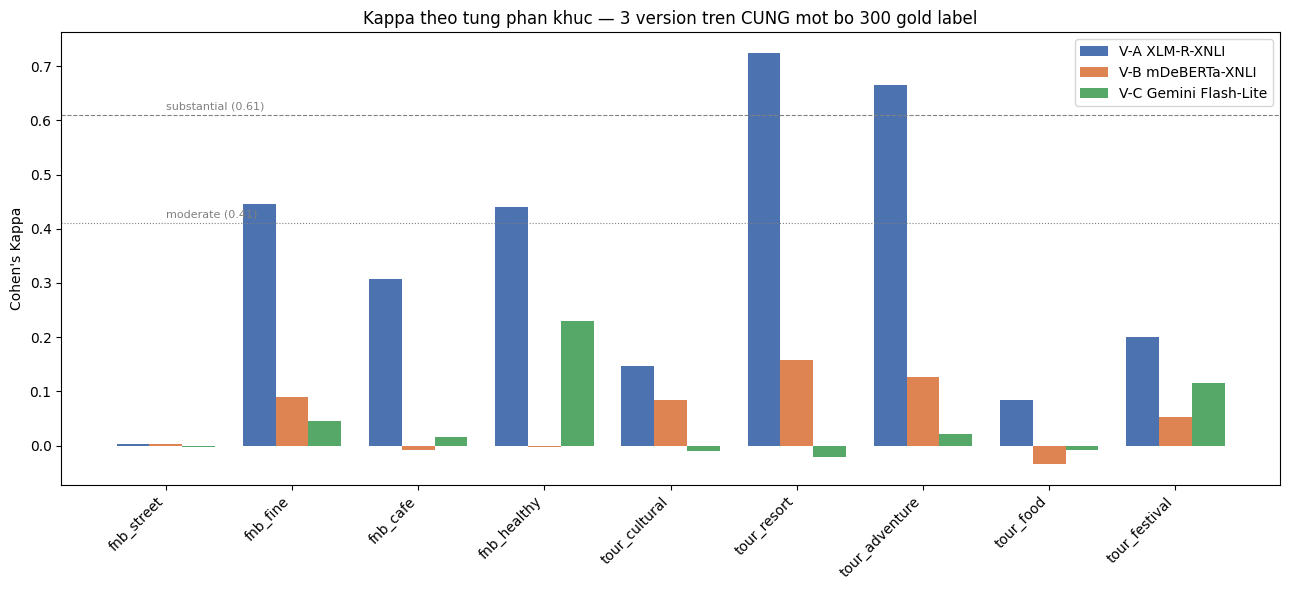

Da luu unified_kappa_per_label.png


In [9]:
summary = pd.DataFrame({
    "Pipeline": ["V-A XLM-R-XNLI", "V-B mDeBERTa-XNLI", "V-C Gemini Flash-Lite"],
    "Macro_Kappa": [macroA, macroB, macroC],
})
summary["Landis_Koch"] = summary["Macro_Kappa"].apply(landis_koch)

# Bang weak labels unification (300 x gold + weakA + weakB + weakC)
comb = gold[["persona_id", "merged_text"] + gold_cols].copy()
for i, lb in enumerate(labels):
    comb[f"weakA_{lb}"] = weakA[:, i]
    comb[f"weakB_{lb}"] = weakB[:, i]
    comb[f"weakC_{lb}"] = weakC[:, i]

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as w:
    summary.to_excel(w, sheet_name="Summary", index=False)
    perlbl.to_excel(w, sheet_name="PerLabel_Kappa", index=False)
    kA.to_excel(w, sheet_name="Agreement_V-A", index=False)
    kB.to_excel(w, sheet_name="Agreement_V-B", index=False)
    kC.to_excel(w, sheet_name="Agreement_V-C", index=False)
    comb.to_excel(w, sheet_name="WeakLabels_unified", index=False)
print(f"Da xuat {OUTPUT_XLSX} (6 sheet).")
print(summary.to_string(index=False))

# Bieu do Kappa tung nhan, 3 version
x = np.arange(len(labels)); w_ = 0.26
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w_, perlbl["V-A"], w_, label="V-A XLM-R-XNLI", color="#4C72B0")
ax.bar(x      , perlbl["V-B"], w_, label="V-B mDeBERTa-XNLI", color="#DD8452")
ax.bar(x + w_, perlbl["V-C"], w_, label="V-C Gemini Flash-Lite", color="#55A868")
ax.axhline(0.61, ls="--", c="gray", lw=0.8); ax.text(0, 0.62, "substantial (0.61)", fontsize=8, c="gray")
ax.axhline(0.41, ls=":", c="gray", lw=0.8); ax.text(0, 0.42, "moderate (0.41)", fontsize=8, c="gray")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Cohen's Kappa"); ax.set_title("Kappa theo tung phan khuc — 3 version tren CUNG mot bo 300 gold label")
ax.legend(); plt.tight_layout(); plt.savefig(PLOT_PATH, dpi=120); plt.show()
print(f"Da luu {PLOT_PATH}")

## 8. Ghi chu

- Bo gold 300 duy nhat lay tu `verA_kappa.xlsx` (sheet `Worksheet`, cot `gold_*`). Nhung persona co gia tri gold khac 0/1 (vd. persona_id 6592, `gold_tour_food=10`) tu dong bi loai khoi Kappa cua nhan tuong ung.
- Nguong thich ung tinh tren chinh 300 persona nay va ap dung dong nhat cho ca 3 version => giao protocol thong nhat, so sanh Kappa lien-pipeline truc tiep.
- V-A o day co the cross-check voi cot `weaklabel_*` co san trong `verA_kappa.xlsx` (ban goc tinh nguong tren 10.000) de danh gia do nham lech do chon nguon nguong (cell tuy chon ben duoi).

In [11]:
# [TUY CHON] Cross-check V-A: ran-lai (nguong 300) vs weaklabel_verA goc (nguong 10.000)
weakA_orig_cols = [f"weaklabel_{lb}" for lb in labels]
if all(c in df_gold_raw.columns for c in weakA_orig_cols):
    weakA_orig = df_gold_raw[weakA_orig_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int).values
    agree = (weakA == weakA_orig).mean(axis=0)
    print("Ty le dong y (re-run V-A nguong 300 vs goc nguong 10.000):")
    for i, lb in enumerate(labels):
        print(f"  {lb:16s}: {agree[i]:.3f}")
    print(f"  Trung binh: {agree.mean():.3f}")
else:
    print("Khong tim thay cot weaklabel_* goc trong verA_kappa.xlsx.")

Ty le dong y (re-run V-A nguong 300 vs goc nguong 10.000):
  fnb_street      : 0.820
  fnb_fine        : 0.980
  fnb_cafe        : 0.967
  fnb_healthy     : 0.947
  tour_cultural   : 0.843
  tour_resort     : 0.980
  tour_adventure  : 0.997
  tour_food       : 0.637
  tour_festival   : 0.727
  Trung binh: 0.877
